# Handwritten digits recognition (using Convolutional Neural Network)

In [ ]:
# Selecting Tensorflow version v2 (the command is relevant for Colab only).
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
import pandas as pd
import math
import datetime
import platform

print('Python version:', platform.python_version())
print('Tensorflow version:', tf.__version__)
print('Keras version:', tf.keras.__version__)

Python version: 3.12.12
Tensorflow version: 2.19.0
Keras version: 3.10.0


## Load the data

The **training** dataset consists of 60000 28x28px images of hand-written digits from `0` to `9`.

The **test** dataset consists of 10000 28x28px images.

In [ ]:
mnist_dataset = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist_dataset.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)

x_train: (60000, 28, 28)
y_train: (60000,)
x_test: (10000, 28, 28)
y_test: (10000,)


In [ ]:
# Save image parameters to the constants that we will use later for data re-shaping and for model traning.
(_, IMAGE_WIDTH, IMAGE_HEIGHT) = x_train.shape
IMAGE_CHANNELS = 1

print('IMAGE_WIDTH:', IMAGE_WIDTH);
print('IMAGE_HEIGHT:', IMAGE_HEIGHT);
print('IMAGE_CHANNELS:', IMAGE_CHANNELS);

IMAGE_WIDTH: 28
IMAGE_HEIGHT: 28
IMAGE_CHANNELS: 1


## Explore the data

Here is how each image in the dataset looks like. It is a 28x28 matrix of integers (from `0` to `255`). Each integer represents a color of a pixel.

In [ ]:
pd.DataFrame(x_train[0])

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,175,26,166,255,247,127,0,0,0,0
6,0,0,0,0,0,0,0,0,30,36,...,225,172,253,242,195,64,0,0,0,0
7,0,0,0,0,0,0,0,49,238,253,...,93,82,82,56,39,0,0,0,0,0
8,0,0,0,0,0,0,0,18,219,253,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,80,156,...,0,0,0,0,0,0,0,0,0,0


This matrix of numbers may be drawn as follows:

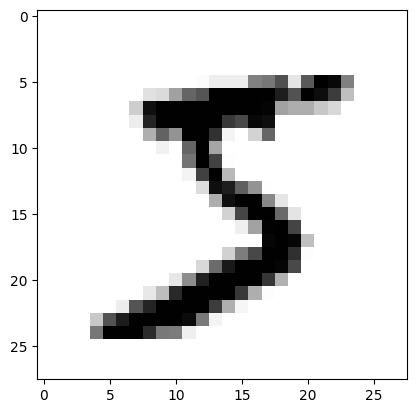

In [ ]:
plt.imshow(x_train[0], cmap=plt.cm.binary)
plt.show()

Let's print some more training examples to get the feeling of how the digits were written.

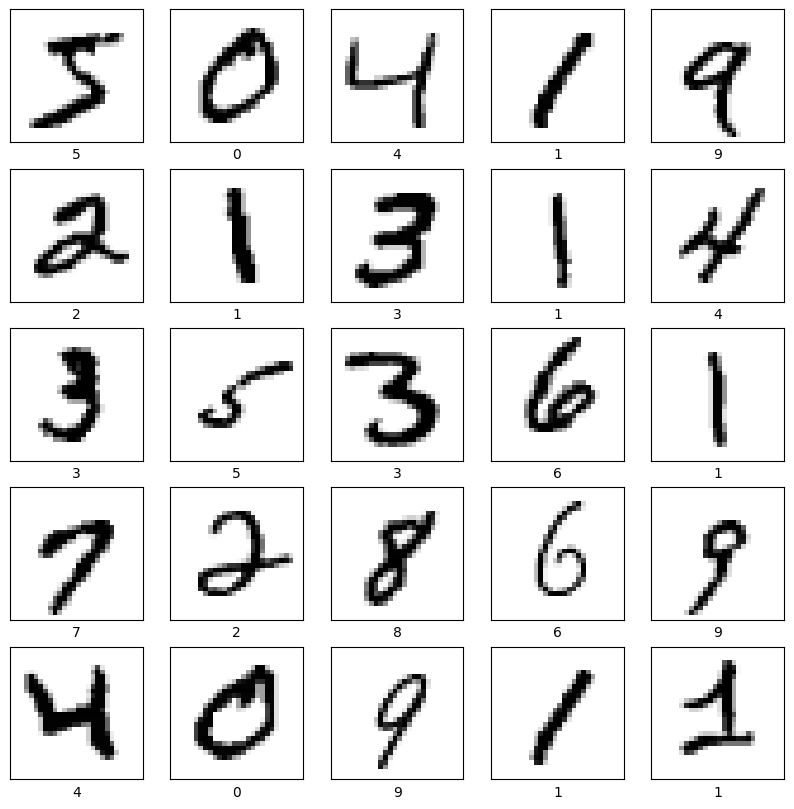

In [ ]:
numbers_to_display = 25
num_cells = math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize=(10,10))
for i in range(numbers_to_display):
    plt.subplot(num_cells, num_cells, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

## Reshaping the data

In order to use convolution layers we need to reshape our data and add a color channel to it. As you've noticed currently every digit has a shape of `(28, 28)` which means that it is a 28x28 matrix of color values form `0` to `255`. We need to reshape it to `(28, 28, 1)` shape so that each pixel potentially may have multiple channels (like Red, Green and Blue).

In [ ]:
x_train_with_chanels = x_train.reshape(
    x_train.shape[0],
    IMAGE_WIDTH,
    IMAGE_HEIGHT,
    IMAGE_CHANNELS
)

x_test_with_chanels = x_test.reshape(
    x_test.shape[0],
    IMAGE_WIDTH,
    IMAGE_HEIGHT,
    IMAGE_CHANNELS
)

In [ ]:
print('x_train_with_chanels:', x_train_with_chanels.shape)
print('x_test_with_chanels:', x_test_with_chanels.shape)

x_train_with_chanels: (60000, 28, 28, 1)
x_test_with_chanels: (10000, 28, 28, 1)


## Normalize the data

Here we're just trying to move from values range of `[0...255]` to `[0...1]`.

In [ ]:
x_train_normalized = x_train_with_chanels / 255
x_test_normalized = x_test_with_chanels / 255

In [ ]:
# Let's check just one row from the 0th image to see color chanel values after normalization.
x_train_normalized[0][18]

array([[0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.18039216],
       [0.50980392],
       [0.71764706],
       [0.99215686],
       [0.99215686],
       [0.81176471],
       [0.00784314],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ]])

#One-hot encoding

In [ ]:

y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

## Build the model

In [ ]:

model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Conv2D(
    64,(3,3),
    strides=(2,2),
    padding='valid',
    activation='relu',
    input_shape=(28,28,1)
))

model.add(tf.keras.layers.Conv2D(
    32,(2,2),
    strides=(1,1),
    padding='same',
    activation='relu'
))

model.add(tf.keras.layers.MaxPooling2D(
    pool_size=(2,2),
    strides=(1,1)
))

model.add(tf.keras.layers.Dropout(0.35))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(
    256,
    activation='tanh'
))

model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.Dense(
    10,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Here is our model summary so far.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 13, 13, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,191,338 (4.54 MB)

 Trainable params: 1,191,338 (4.54 MB)

 Non-trainable params: 0 (0.00 B)

In order to plot the model the `graphviz` should be installed. For Mac OS it may be installed using `brew` like `brew install graphviz`.

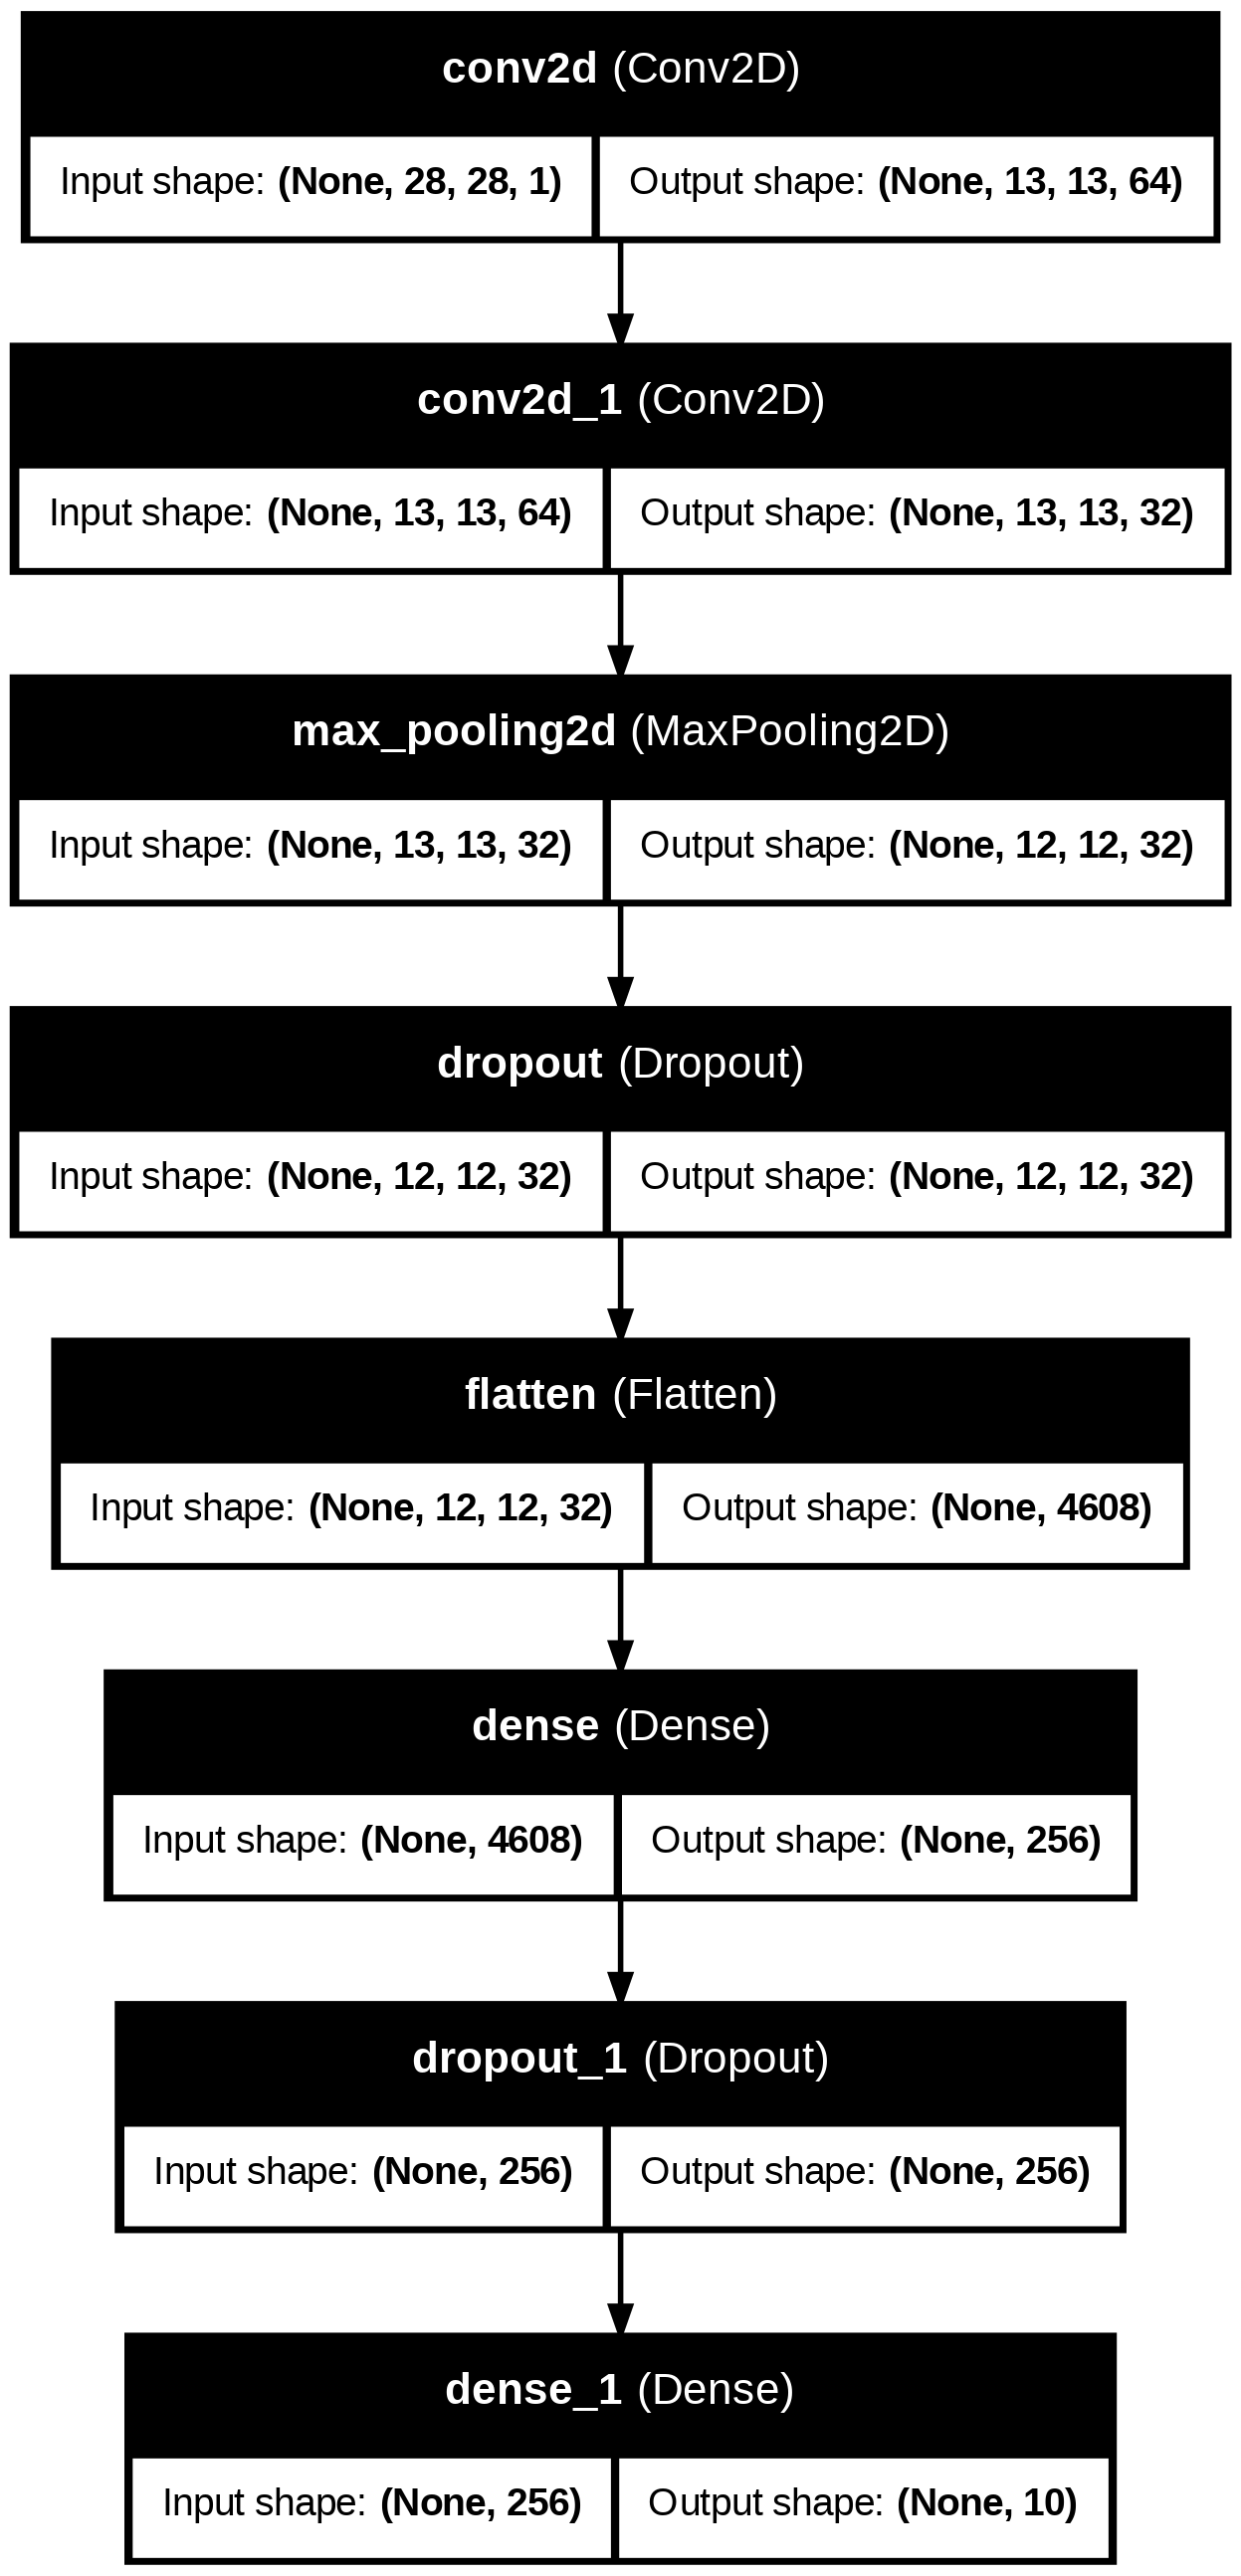

In [ ]:
tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
)

## Compile and train the model

In [ ]:

import datetime

optimizers = {
    "Adam": tf.keras.optimizers.Adam(),
    "Adadelta": tf.keras.optimizers.Adadelta(),
    "SGD": tf.keras.optimizers.SGD()
}

histories = {}

for name, opt in optimizers.items():

    print("Training with:", name)

    log_dir = "logs/fit/" + name + "_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1
    )

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_normalized,
        y_train_cat,
        epochs=10,
        validation_data=(x_test_normalized, y_test_cat),
        callbacks=[tensorboard_callback]
    )

    histories[name] = history

Training with: Adam
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9105 - loss: 0.2832 - val_accuracy: 0.9843 - val_loss: 0.0493
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9771 - loss: 0.0721 - val_accuracy: 0.9847 - val_loss: 0.0469
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9825 - loss: 0.0557 - val_accuracy: 0.9867 - val_loss: 0.0416
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9856 - loss: 0.0448 - val_accuracy: 0.9895 - val_loss: 0.0335
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9876 - loss: 0.0370 - val_accuracy: 0.9876 - val_loss: 0.0401
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9885 - loss: 0.0355 - val_accuracy: 0.9889 - val_loss: 0.0346
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9896 - loss: 0.0311 - val_accuracy: 0.9893 - val_loss: 0.0363
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.

Let's see how the loss function was changing during the training. We expect it to get smaller and smaller on every next epoch for each optimizer.

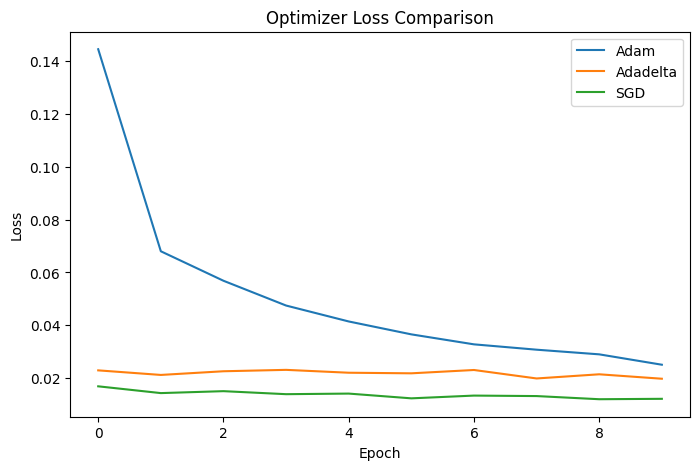

In [ ]:

plt.figure(figsize=(8,5))

for name, history in histories.items():
    plt.plot(history.history['loss'], label=name)

plt.title("Optimizer Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

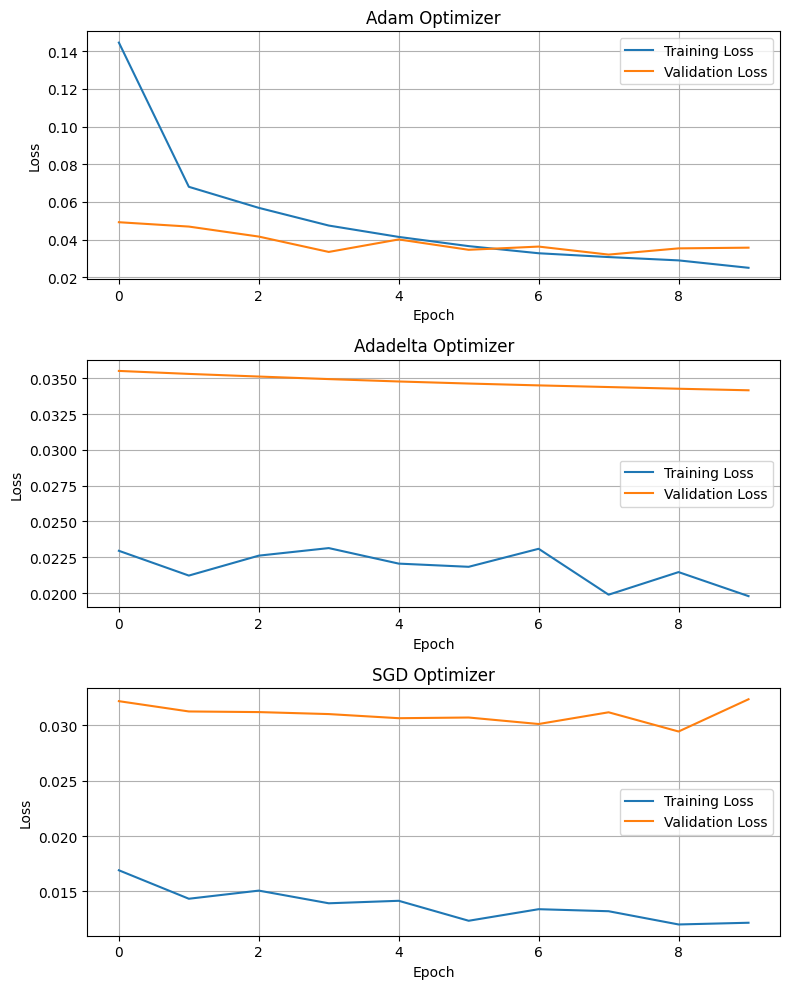

In [ ]:

fig, axes = plt.subplots(3, 1, figsize=(8,10))

optim_names = list(histories.keys())

for i, name in enumerate(optim_names):

    history = histories[name]

    axes[i].plot(history.history['loss'], label='Training Loss')
    axes[i].plot(history.history['val_loss'], label='Validation Loss')

    axes[i].set_title(f"{name} Optimizer")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")

    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()

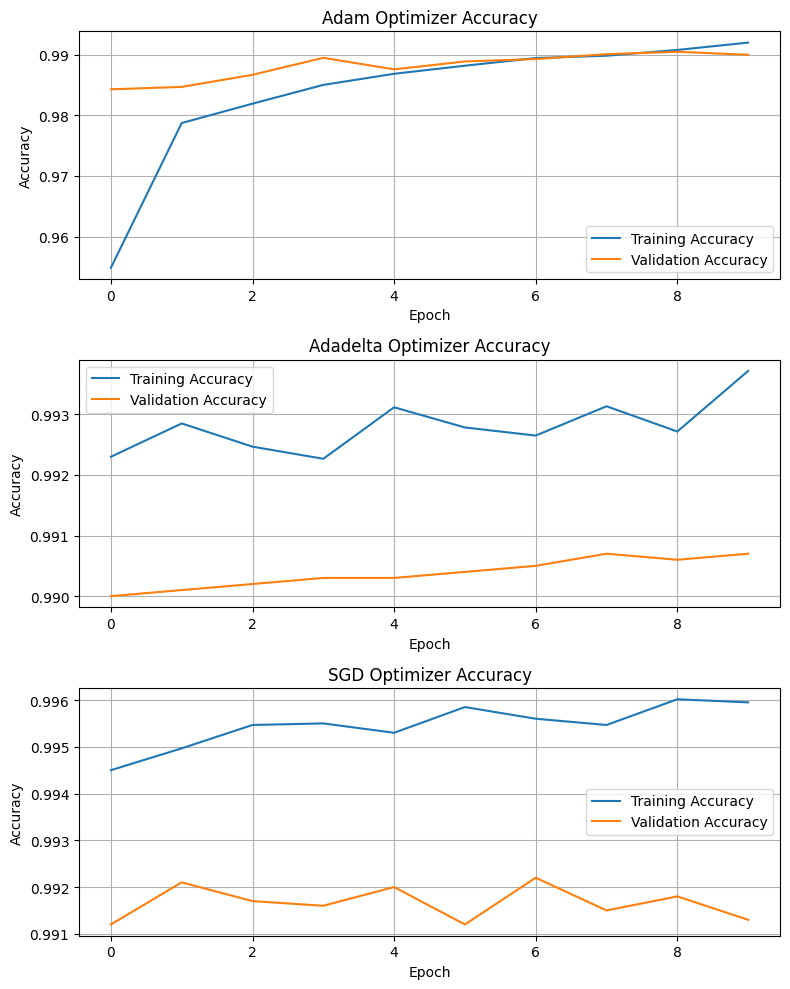

In [ ]:

fig, axes = plt.subplots(3, 1, figsize=(8,10))

optim_names = list(histories.keys())

for i, name in enumerate(optim_names):

    history = histories[name]

    axes[i].plot(history.history['accuracy'], label='Training Accuracy')
    axes[i].plot(history.history['val_accuracy'], label='Validation Accuracy')

    axes[i].set_title(f"{name} Optimizer Accuracy")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Accuracy")

    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()

## Evaluate best model accuracy

We need to compare the accuracy of our model on **training** set and on **test** set. We expect our model to perform similarly on both sets. If the performance on a test set will be poor comparing to a training set it would be an indicator for us that the model is overfitted and we have a "high variance" issue.

In [ ]:

train_loss, train_acc = model.evaluate(x_train_normalized, y_train_cat, verbose=0)
test_loss, test_acc = model.evaluate(x_test_normalized, y_test_cat, verbose=0)

print("Model Evaluation")
print("Training Loss:", train_loss)
print("Training Accuracy:", train_acc)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Model Evaluation
Training Loss: 0.0029704319313168526
Training Accuracy: 0.9991499781608582
Test Loss: 0.032322756946086884
Test Accuracy: 0.9912999868392944


## Save the Best model

In [ ]:
model_name = 'digits_recognition_cnn.h5'
model.save(model_name, save_format='h5')

In [ ]:
model.save("mnist_cnn_adam_model.h5")

In [ ]:


predictions = model.predict(x_test_normalized)

predicted_label = np.argmax(predictions[0])

print("Predicted Digit:", predicted_label)
print("Actual Digit:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted Digit: 7
Actual Digit: 7


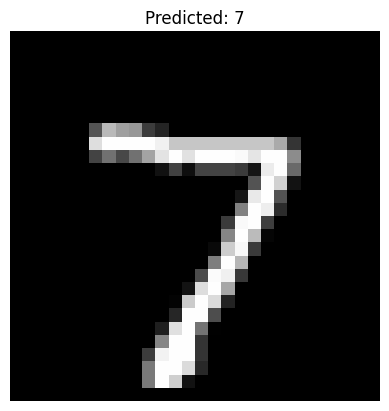

In [ ]:


plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_label}")
plt.axis("off")
plt.show()

## Use the model (do predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


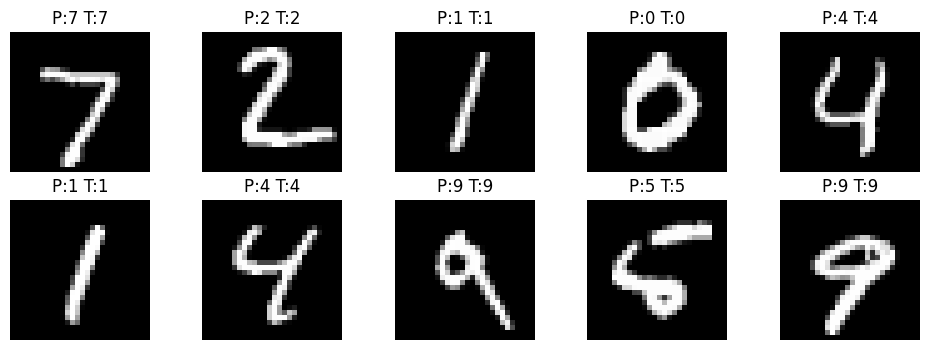

In [ ]:

predictions = model.predict(x_test_normalized)

plt.ffigureigure(figsize=(12,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i], cmap='gray')

    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i]

    plt.title(f"P:{predicted_label} T:{true_label}")
    plt.axis('off')

plt.show()

## Plotting a confusion matrix

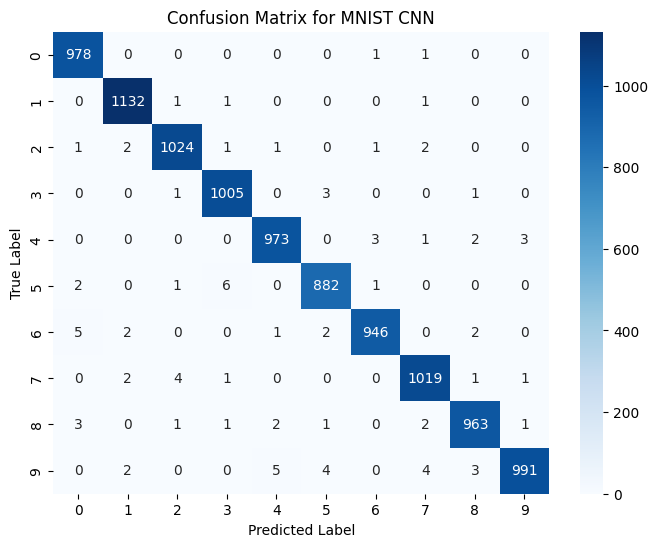

In [ ]:
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for MNIST CNN")

plt.show()